Initial donor mass:     1.100000 Msun
Initial accretor mass:  0.400000 Msun
Initial donor RL radius: 3.589910e-03 AU
Configured RLMT: N=2, donor=0, accretor=1


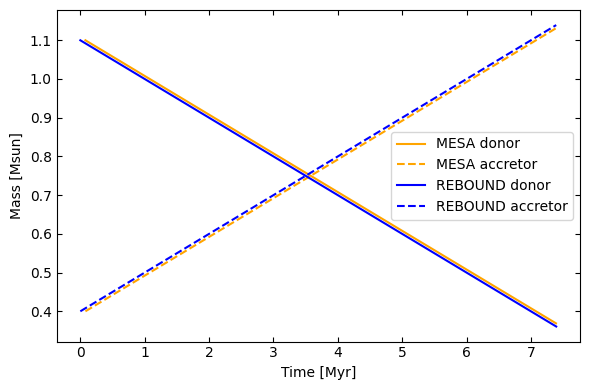

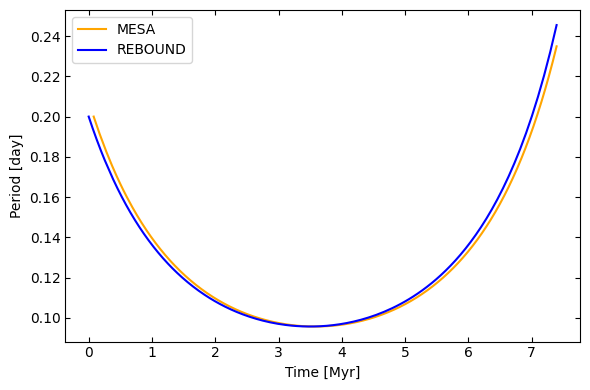

In [3]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rebound
import reboundx


def eggleton_roche_lobe_over_a(q):
    """Return Roche-lobe radius divided by orbital separation."""
    q_1_3 = q ** (1.0 / 3.0)
    q_2_3 = q_1_3 * q_1_3
    return 0.49 * q_2_3 / (0.6 * q_2_3 + math.log(1.0 + q_1_3))


# -----------------------
# Build a simple 2-body binary
# -----------------------
sim = rebound.Simulation()
sim.units = ("AU", "yr", "Msun")
sim.integrator = "whfast"
sim.dt = 1.0

donor_mass = 1.1
accretor_mass = 0.4
stellar_radius_au = 0.00465
orbital_period_yr = 0.2 / 365.0
orbital_eccentricity = 1e-4

# Particle 0 = donor, particle 1 = accretor
sim.add(m=donor_mass, r=stellar_radius_au)
sim.add(m=accretor_mass, P=orbital_period_yr, e=orbital_eccentricity, r=stellar_radius_au)
sim.move_to_com()

donor = sim.particles[0]
accretor = sim.particles[1]

# Print a short initial summary
q_init = donor.m / accretor.m
rl_init = eggleton_roche_lobe_over_a(q_init) * accretor.a

print(f"Initial donor mass:     {donor.m:.6f} Msun")
print(f"Initial accretor mass:  {accretor.m:.6f} Msun")
print(f"Initial donor RL radius: {rl_init:.6e} AU")

# -----------------------
# Roche-lobe mass transfer
# -----------------------
rebx = reboundx.Extras(sim)
rlmt = rebx.load_operator("roche_lobe_mass_transfer")
rebx.add_operator(rlmt)

# Operator settings
rlmt.params["rlmt_donor"] = 0
rlmt.params["rlmt_accretor"] = 1
rlmt.params["rlmt_skip_in_CE"] = 1
rlmt.params["rlmt_loss_fraction"] = 0.0
rlmt.params["jloss_mode"] = 0
rlmt.params["rlmt_substep_max_dm"] = 0.1
rlmt.params["rlmt_substep_max_dr"] = 1000.0
rlmt.params["rlmt_min_substeps"] = 2

# Donor-only mass-transfer parameters
donor.params["rlmt_Hp"] = 1.0e4
donor.params["rlmt_mdot0"] = 1.0e-7

print(
    f"Configured RLMT: N={sim.N}, "
    f"donor={rlmt.params['rlmt_donor']}, "
    f"accretor={rlmt.params['rlmt_accretor']}"
)

# -----------------------
# Integrate and store results
# -----------------------
time_years = []
donor_mass_history = []
accretor_mass_history = []
period_days_history = []

sample_times = np.logspace(1, np.log10(7.3928e6), 1000)

for t in sample_times:
    sim.integrate(t)

    # Stop if the binary is reduced to a single body
    if sim.N == 1:
        sole_particle = sim.particles[0]
        print(f"System reduced to one body at t={sim.t:.6e} yr, mass={sole_particle.m:.6f} Msun")
        break

    donor = sim.particles[0]
    accretor = sim.particles[1]

    time_years.append(sim.t)
    donor_mass_history.append(donor.m)
    accretor_mass_history.append(accretor.m)
    period_days_history.append(365.0 * accretor.P)

# Convert to arrays for plotting
time_myr = np.asarray(time_years) / 1.0e6
donor_mass_history = np.asarray(donor_mass_history)
accretor_mass_history = np.asarray(accretor_mass_history)
period_days_history = np.asarray(period_days_history)

# -----------------------
# Load MESA comparison data
# -----------------------
mesa_donor = pd.read_csv("./mesa/history.data1", header=0, skiprows=5, sep=r"\s+")
mesa_accretor = pd.read_csv("./mesa/history.data2", header=0, skiprows=5, sep=r"\s+")
mesa_binary = pd.read_csv("./mesa/binary_history.data", header=0, skiprows=5, sep=r"\s+")

# -----------------------
# Plot mass evolution
# -----------------------
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(mesa_donor["star_age"] / 1.0e6, mesa_donor["star_mass"], c="orange", label="MESA donor")
ax.plot(
    mesa_accretor["star_age"] / 1.0e6,
    mesa_accretor["star_mass"],
    c="orange",
    ls="--",
    label="MESA accretor",
)
ax.plot(time_myr, donor_mass_history, c="b", label="REBOUND donor")
ax.plot(time_myr, accretor_mass_history, c="b", ls="--", label="REBOUND accretor")

ax.set_xlabel("Time [Myr]")
ax.set_ylabel("Mass [Msun]")
ax.tick_params(direction="in", top=True, right=True)
ax.legend(loc=0)

fig.tight_layout()
plt.show()

# -----------------------
# Plot orbital period evolution
# -----------------------
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(mesa_binary["age"] / 1.0e6, mesa_binary["period_days"], c="orange", label="MESA")
ax.plot(time_myr, period_days_history, c="b", label="REBOUND")

ax.set_xlabel("Time [Myr]")
ax.set_ylabel("Period [day]")
ax.tick_params(direction="in", top=True, right=True)
ax.legend(loc=0)

fig.tight_layout()
plt.show()